### hypothesis 1: Do we see more early movement in the trial immediately after a trial in which movement was locked early (and players didn't move)?
####    sub-hypothesis: do we see more movement for the previous-trial loser compared to the previous-trial winner? 

## First-pass analysis: movement rebound after an early lock

In the corridor game two squares advance toward each other; each can switch
**lane** (0/1) until control locks at a *uniformly-random* `random_time_ms`
(the control cutoff, ~1.0–4.0 s). The matcher wins on a collision (same lane),
the avoider on a pass.

**Hypothesis 1.** After a trial where control locked *early* and the player did
not move, does that player move *earlier* in the next trial?
**Sub-hypothesis.** Is any such rebound larger for the previous-trial **loser**
than the **winner**?

We measure each player's movement per trial from the command log, build a
trial-history panel, and compare next-trial movement by what happened before.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from parse_games import build_all

tables = build_all()
trials, commands = tables["trials"], tables["commands"]

cor = trials[trials.game == "corridor"].set_index("trial")
positions = commands[commands.msg_type == "position"].sort_values("server_ts_ms")

print(f"{len(cor)} trials | control cutoff {cor.random_time_ms.min():.0f}-"
      f"{cor.random_time_ms.max():.0f} ms (median {cor.random_time_ms.median():.0f})")
cor[["matcher_start_lane", "avoider_start_lane", "matcher_action",
     "avoider_action", "matched", "matcher_won", "random_time_ms"]].head()

100 trials | control cutoff 1006-3996 ms (median 2692)


,matcher_start_lane,avoider_start_lane,matcher_action,avoider_action,matched,matcher_won,random_time_ms
trial,,,,,,,
1,1.0,1.0,1,1,True,True,3513
2,0.0,1.0,0,1,False,False,1797
3,1.0,1.0,1,1,True,True,1715
4,1.0,0.0,1,0,False,False,3199
5,1.0,0.0,1,1,True,True,3996


### Operationalising 'movement'

The command log records a `position` message for the lane at each update; the
**first** one is just the starting lane, so a *move* = a lane **change**.
Per (trial, player) we compute:

* **`n_moves`** *[full trial]* – number of lane changes
* **`first_move_t`** *[full trial]* – time of the first lane change (ms from trial start); lower = earlier
* **`moves_1s`** *[first 1 s]* – lane changes within the first second
* **`moved`** – whether the player changed lane at all

`player_id` 1 = matcher, 2 = avoider, and the **same two people play every
trial**, so we can line up each player's *previous* trial.

In [2]:
def move_feats(g):
    g = g.sort_values("server_ts_ms")
    lanes, t = g.lane.values, g.t_rel_ms.values
    change = np.where(lanes[1:] != lanes[:-1])[0] + 1     # indices of lane changes
    n = len(change)
    return pd.Series(dict(
        n_moves=n,
        first_move_t=t[change[0]] if n else np.nan,
        moves_1s=int(np.sum(t[change] < 1000)) if n else 0,
        moved=n > 0))

mv = (positions.groupby(["trial", "player_id"])
               .apply(move_feats, include_groups=False).reset_index())

# outcome + cutoff for each player-trial (player 1 = matcher, 2 = avoider)
mv["won"] = [bool(cor.loc[tr, "matcher_won" if pid == 1 else "avoider_won"])
             for tr, pid in zip(mv.trial, mv.player_id)]
mv["cutoff"] = mv.trial.map(cor.random_time_ms)

# an 'early lock' = control cut off in the lowest third of cutoff times
early_thr = cor.random_time_ms.quantile(1 / 3)
mv["early_lock"] = mv.cutoff < early_thr
print(f"early-lock threshold (lower-tertile cutoff) = {early_thr:.0f} ms")
mv.head()

early-lock threshold (lower-tertile cutoff) = 2095 ms


,trial,player_id,n_moves,first_move_t,moves_1s,moved,won,cutoff,early_lock
0,1,1,2,2441.545166,0,True,True,3513,False
1,1,2,2,2813.927490,0,True,False,3513,False
2,2,1,0,NaN,0,False,False,1797,True
3,2,2,0,NaN,0,False,True,1797,True
4,3,1,0,NaN,0,False,True,1715,True


### Sanity check — early locks really do suppress movement

If the trigger is meaningful, an early control cutoff should leave players
unable to move. It does:

              n  mean_n_moves  p_no_move
later lock  134         2.560      0.052
early lock   66         1.015      0.333


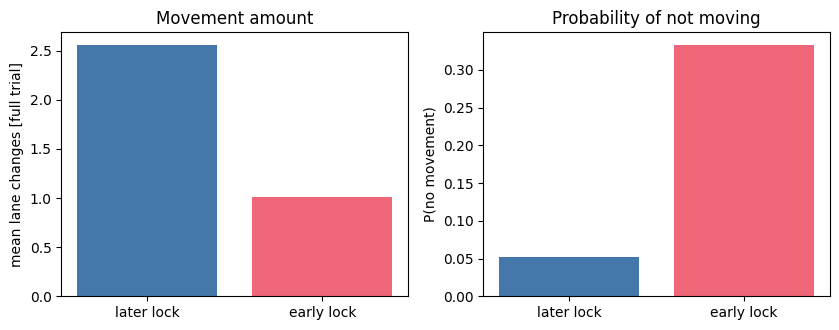

In [3]:
chk = (mv.groupby("early_lock")
         .agg(n=("moved", "size"),
              mean_n_moves=("n_moves", "mean"),
              p_no_move=("moved", lambda s: 1 - s.mean()))
         .round(3))
chk.index = ["later lock", "early lock"]
print(chk.to_string())

fig, ax = plt.subplots(1, 2, figsize=(8.5, 3.4))
ax[0].bar(chk.index, chk.mean_n_moves, color=["#4477aa", "#ee6677"])
ax[0].set(ylabel="mean lane changes [full trial]", title="Movement amount")
ax[1].bar(chk.index, chk.p_no_move, color=["#4477aa", "#ee6677"])
ax[1].set(ylabel="P(no movement)", title="Probability of not moving")
fig.tight_layout()

### Trial-history panel

Shift each player's record by one trial to get the *previous* trial's
attributes. The Hypothesis-1 trigger is **`prev_earlylock_nomove`**: the
previous trial was an early lock in which this player did not move. We then
split those follow-up trials by whether the player **won or lost** that
previous (forced) trial.

In [4]:
mv = mv.sort_values(["player_id", "trial"])
for c in ["early_lock", "moved", "won"]:
    mv["prev_" + c] = mv.groupby("player_id")[c].shift(1)
mv["prev_earlylock_nomove"] = (mv.prev_early_lock & (~mv.prev_moved.astype("boolean")))

panel = mv.dropna(subset=["prev_moved"]).copy()          # drop each player's first trial
panel["prev_earlylock_nomove"] = panel.prev_earlylock_nomove.astype(bool)
panel["group"] = np.where(~panel.prev_earlylock_nomove, "other",
                  np.where(panel.prev_won, "after early-lock no-move (prev WON)",
                                           "after early-lock no-move (prev LOST)"))
panel.group.value_counts()

group
other                                   176
after early-lock no-move (prev LOST)     16
after early-lock no-move (prev WON)       6
Name: count, dtype: int64

### Hypothesis 1 + sub-hypothesis: next-trial movement by history

In [5]:
order = ["other",
         "after early-lock no-move (prev LOST)",
         "after early-lock no-move (prev WON)"]
res = (panel.groupby("group")
            .agg(n=("first_move_t", "size"),
                 first_move_t_ms=("first_move_t", "mean"),
                 moves_1s=("moves_1s", "mean"),
                 n_moves=("n_moves", "mean"))
            .reindex(order).round(2))
res

,n,first_move_t_ms,moves_1s,n_moves
group,,,,
other,176,1079.81,0.57,2.07
after early-lock no-move (prev LOST),16,996.64,0.38,2.19
after early-lock no-move (prev WON),6,1649.42,0.17,1.17


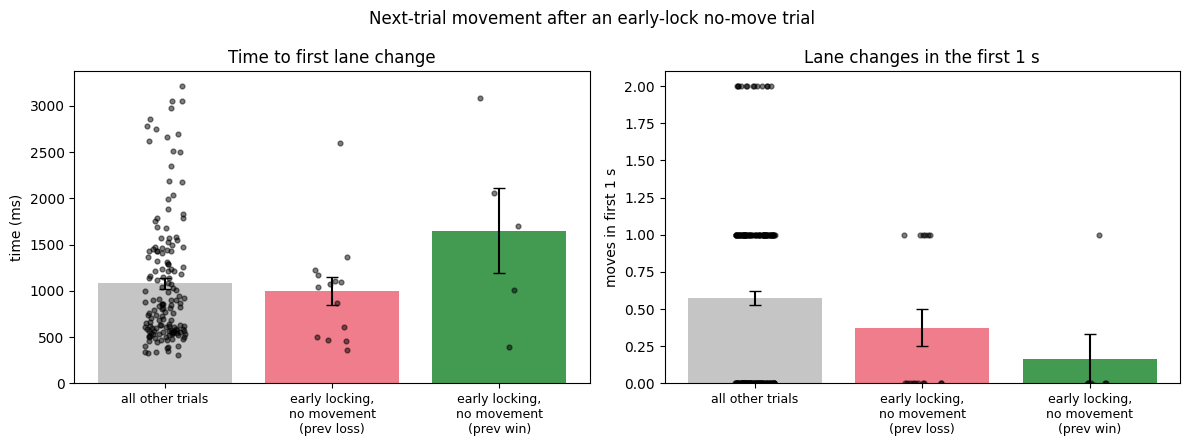

In [6]:
np.random.seed(0)

def mean_sem(s):
    s = s.dropna()
    return s.mean(), (s.std(ddof=1) / np.sqrt(len(s)) if len(s) > 1 else 0.0)

colours = ["#bbbbbb", "#ee6677", "#228833"]
labels = ["all other trials",
          "early locking,\nno movement\n(prev loss)",
          "early locking,\nno movement\n(prev win)"]

fig, ax = plt.subplots(1, 2, figsize=(12, 4.5))
for a, metric, ttl, yl in [
        (ax[0], "first_move_t",
         "Time to first lane change", "time (ms)"),
        (ax[1], "moves_1s",
         "Lane changes in the first 1 s", "moves in first 1 s")]:
    means, sems, pts = [], [], []
    for grp in order:
        s = panel.loc[panel.group == grp, metric]
        m, e = mean_sem(s); means.append(m); sems.append(e); pts.append(s.dropna().values)
    x = np.arange(3)
    a.bar(x, means, yerr=sems, color=colours, capsize=4, alpha=.85)
    for i, p in enumerate(pts):                      # individual points (groups are small)
        a.scatter(i + np.random.uniform(-.12, .12, len(p)), p, color="k", s=12, alpha=.5, zorder=3)
    a.set_xticks(x); a.set_xticklabels(labels, fontsize=9); a.set(title=ttl, ylabel=yl)
fig.suptitle("Next-trial movement after an early-lock no-move trial ")
fig.tight_layout()

### Variant trigger: early lock with *at most one* movement

Same analysis as the figure above, but the trigger now also includes previous
trials in which the player made **one** lane change (`prev_n_moves <= 1`), not
only zero. Everything else is identical — the original no-movement figure above
is left unchanged.

In [7]:
# Variant trigger: previous trial was an early lock with AT MOST ONE movement
# (prev_n_moves <= 1), instead of strictly no movement. Same analysis -> panel2.
mv["prev_n_moves"] = mv.groupby("player_id")["n_moves"].shift(1)
mv["prev_earlylock_le1"] = (mv.prev_early_lock & (mv.prev_n_moves <= 1))

panel2 = mv.dropna(subset=["prev_moved"]).copy()          # drop each player's first trial
panel2["prev_earlylock_le1"] = panel2.prev_earlylock_le1.astype(bool)
panel2["group"] = np.where(~panel2.prev_earlylock_le1, "other",
                   np.where(panel2.prev_won, "after early-lock <=1 move (prev WON)",
                                             "after early-lock <=1 move (prev LOST)"))
order2 = ["other",
          "after early-lock <=1 move (prev LOST)",
          "after early-lock <=1 move (prev WON)"]
res2 = (panel2.groupby("group")
              .agg(n=("first_move_t", "size"),
                   first_move_t_ms=("first_move_t", "mean"),
                   moves_1s=("moves_1s", "mean"),
                   n_moves=("n_moves", "mean"))
              .reindex(order2).round(2))
res2

,n,first_move_t_ms,moves_1s,n_moves
group,,,,
other,148,1152.77,0.52,1.93
after early-lock <=1 move (prev LOST),27,851.99,0.63,2.63
after early-lock <=1 move (prev WON),23,996.91,0.61,2.13


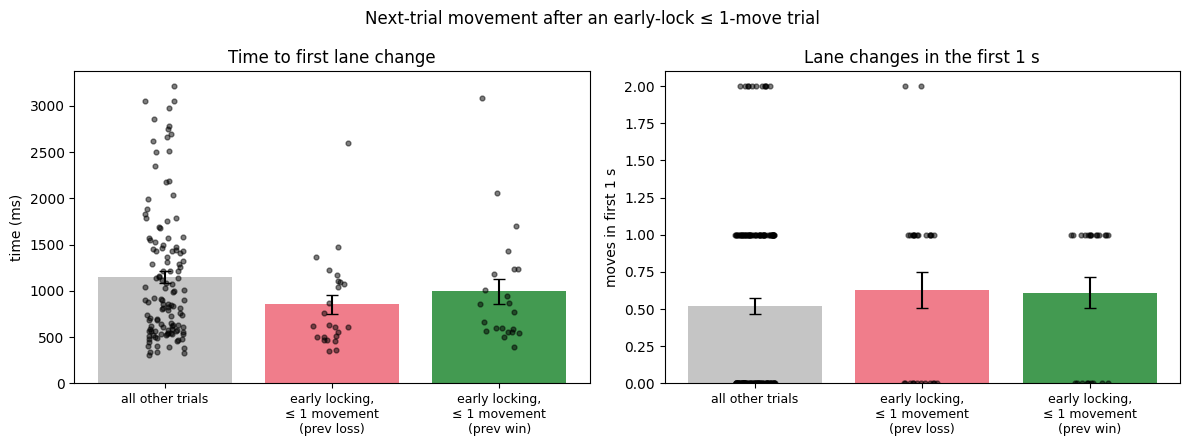

In [8]:
np.random.seed(0)

def mean_sem(s):
    s = s.dropna()
    return s.mean(), (s.std(ddof=1) / np.sqrt(len(s)) if len(s) > 1 else 0.0)

colours = ["#bbbbbb", "#ee6677", "#228833"]
labels = ["all other trials",
          "early locking,\n≤ 1 movement\n(prev loss)",
          "early locking,\n≤ 1 movement\n(prev win)"]

fig, ax = plt.subplots(1, 2, figsize=(12, 4.5))
for a, metric, ttl, yl in [
        (ax[0], "first_move_t",
         "Time to first lane change", "time (ms)"),
        (ax[1], "moves_1s",
         "Lane changes in the first 1 s", "moves in first 1 s")]:
    means, sems, pts = [], [], []
    for grp in order2:
        s = panel2.loc[panel2.group == grp, metric]
        m, e = mean_sem(s); means.append(m); sems.append(e); pts.append(s.dropna().values)
    x = np.arange(3)
    a.bar(x, means, yerr=sems, color=colours, capsize=4, alpha=.85)
    for i, p in enumerate(pts):                      # individual points (groups are small)
        a.scatter(i + np.random.uniform(-.12, .12, len(p)), p, color="k", s=12, alpha=.5, zorder=3)
    a.set_xticks(x); a.set_xticklabels(labels, fontsize=9); a.set(title=ttl, ylabel=yl)
fig.suptitle("Next-trial movement after an early-lock ≤ 1-move trial ")
fig.tight_layout()

### First-pass findings

* **Early locks suppress movement (as expected).** Under an early lock players changed lane ~1.0 times and failed to move at all ~33% of the time, vs ~2.6 changes and ~5% no-move under later locks — confirming the trigger captures forced, no-movement trials.

* **Hypothesis 1, as stated, is *not* supported.** Averaged over everyone, trials following an early-lock no-move do **not** show earlier movement (first lane change ≈ 1168 ms vs ≈ 1080 ms in baseline trials — if anything slightly *later*), and no more early moves.

* **The sub-hypothesis *is* supported, and it drives the effect.** Splitting those follow-up trials by the previous outcome is striking: previous-trial **losers** began moving ~650 ms **earlier** (≈ 997 ms vs ≈ 1649 ms) and made about **double** the early moves (≈ 0.38 vs ≈ 0.17 in the first second; ≈ 2.2 vs ≈ 1.2 total) compared with previous-trial **winners**. After being handed a bad outcome by an early lock they couldn't act on, players get on the move sooner; players who happened to *win* that forced trial stay passive.

* **It's an interaction, not a general win/lose effect.** Across *all* transitions, previous winners and losers move almost identically (first change ≈ 1055 vs ≈ 1127 ms). The early-movement rebound appears specifically in the *early-lock × lost* cell.

**Caveats & next steps**
1. One player pair, 100 trials; the key sub-group is only **22 player-trials (16 lost / 6 won)** — treat as suggestive, not significance-tested. Use a permutation test / mixed-effects model with player as a random effect.
2. Robustness: try a trial-level "*both* players didn't move" trigger and vary the early-lock threshold.
3. Does the effect differ by **role** (matcher vs avoider)?
4. Relate to the original note on an **internal cooldown** (rate-limited lane switching here vs none in the matching-pennies game) — does the cooldown shape how quickly players can act on this rebound?